In [1]:
from typing import Dict, List, Any, Tuple

from model_ranking import (
    get_summary_results, 
    per_source_model_results,
    correlation_table,
    to_target_transfer_correlations_with_norm,
    per_target_consis_result_type,
    per_target_performance_result_type,
)
from model_ranking import plot_alpha_sweep_specific_norm

INFO: P [MainThread] 2025-11-18 14:16:52,361 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


/g/kreshuk/talks/pytorch-3dunet/pytorch3dunet/unet3d/utils.py:17: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/g/kreshuk/talks/miniforge3/envs/model-rank-local2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
Unet_source_models = {
    "BBBC039": "BC_IN_model2",
    #"Go-Nuclear": "GN_IN_model1",
    "HeLaNuc": "HN_IN_model2",
    "Hoechst": "Hst_IN_model3",
    "S_BIAD895": "895_IN_model2",
    "S_BIAD1410": "1410_IN_model1",
}
consis_keys = {
    "BBBC039": "ARE2_th00",
    "DSB2018": "ARE2_th00",
    "Go-Nuclear": "ARE2_th00",
    "Hoechst": "ARE2_th00",
    "S_BIAD634": "ARE2_th00",
    "S_BIAD895": "ARE2_th00",
}
result_folders = {
    "BBBC039": "P1",
    "DSB2018": "P1",
    "Go-Nuclear": "P1",
    "HeLaNuc": "P1",
    "Hoechst": "P1",
    "S_BIAD634": "P1",
    "S_BIAD895": "P1",
    "S_BIAD1196": "P1",
    "S_BIAD1410": "P1",
}

per_target_norms: Dict[str, List[Tuple[float, float]]] = {
    "BBBC039": [(5, 98)],
    "DSB2018": [(5, 98)],
    "Go-Nuclear": [(0, 99.8)],
    "HeLaNuc": [(5, 99.6)],
    "Hoechst": [(5, 98)],
    "S_BIAD634": [(5, 98)],
    "S_BIAD895": [(5, 98)],
    "S_BIAD1196": [(5, 98)],
    "S_BIAD1410": [(5, 98)],
}

perf_key = "MAP_05_095"
approach = "consistency"
base_result_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/nuclei"

In [3]:
summary_results_postfix = ""
selected_augmentations = {
    "none": [""],
    #"gauss": ["a0-005", "a005-01", "a01-02"],
    "gamma": ["a08-09", "a09-095", "a105-11", "a11-12"]
    #"brt": ["a00-005", "a005-01", "a01-02"]
    #"ctr": ["a08-09", "a09-095", "a105-11", "a11-12"]
}
targets = [
    "BBBC039",
    "DSB2018", 
    #"Go-Nuclear", 
    #"HeLaNuc", 
    "Hoechst", 
    "S_BIAD895", 
    "S_BIAD634",
    #"S_BIAD1196", 
    #"S_BIAD1410"
]
source_model_types = [Unet_source_models]

In [5]:
per_target_forg_consistency: per_target_consis_result_type= {}
per_target_forg_performance: per_target_performance_result_type = {}
for i, target in enumerate(targets):

    per_source_forg_consistency = {}
    per_source_forg_performance = {}

    for model_type in source_model_types:
        sources = list(model_type.keys())
        if ((target == "HeLaNuc") and ("HeLaNuc" in sources)):
            sources.remove("HeLaNuc")
        if ((target == "S_BIAD895") and ("S_BIAD895" in sources)):
            sources.remove("S_BIAD895")
        if ((target == "S_BIAD1196") and ("S_BIAD1196" in sources)):
            sources.remove("S_BIAD1196")
        if ((target == "S_BIAD1410") and ("S_BIAD1410" in sources)):
            sources.remove("S_BIAD1410")
            
        consis_str, _, NA_perf = get_summary_results(
            source_data=sources,
            target_data=[target],
            source_models = model_type,
            selected_augmentations=selected_augmentations,
            selected_norms=per_target_norms,
            consis_keys=consis_keys,
            perf_key=perf_key,
            per_target_norms=True,
            result_folders=result_folders,
            approach=approach,
            consis_postfix="median_per_alpha",
            perf_postfix="median",
            summary_results_postfix=summary_results_postfix,
            base_seg_dir=base_result_path,
        )
        per_source_forg_consistency.update(
            per_source_model_results(
                consis_str, 
                source_models=model_type, 
            ))
        per_source_forg_performance.update(
            per_source_model_results(
                NA_perf, 
                source_models=model_type,
            ))
    
    per_target_forg_consistency[target] = per_source_forg_consistency
    per_target_forg_performance[target] = per_source_forg_performance


Source: BBBC039


100%|██████████| 1/1 [00:00<00:00,  8.48it/s]


Source: HeLaNuc


100%|██████████| 1/1 [00:00<00:00,  7.49it/s]


Source: Hoechst


...

100%|██████████| 1/1 [00:00<00:00,  9.34it/s]


Source: S_BIAD895


100%|██████████| 1/1 [00:00<00:00,  7.62it/s]


Source: S_BIAD1410


100%|██████████| 1/1 [00:00<00:00,  8.34it/s]


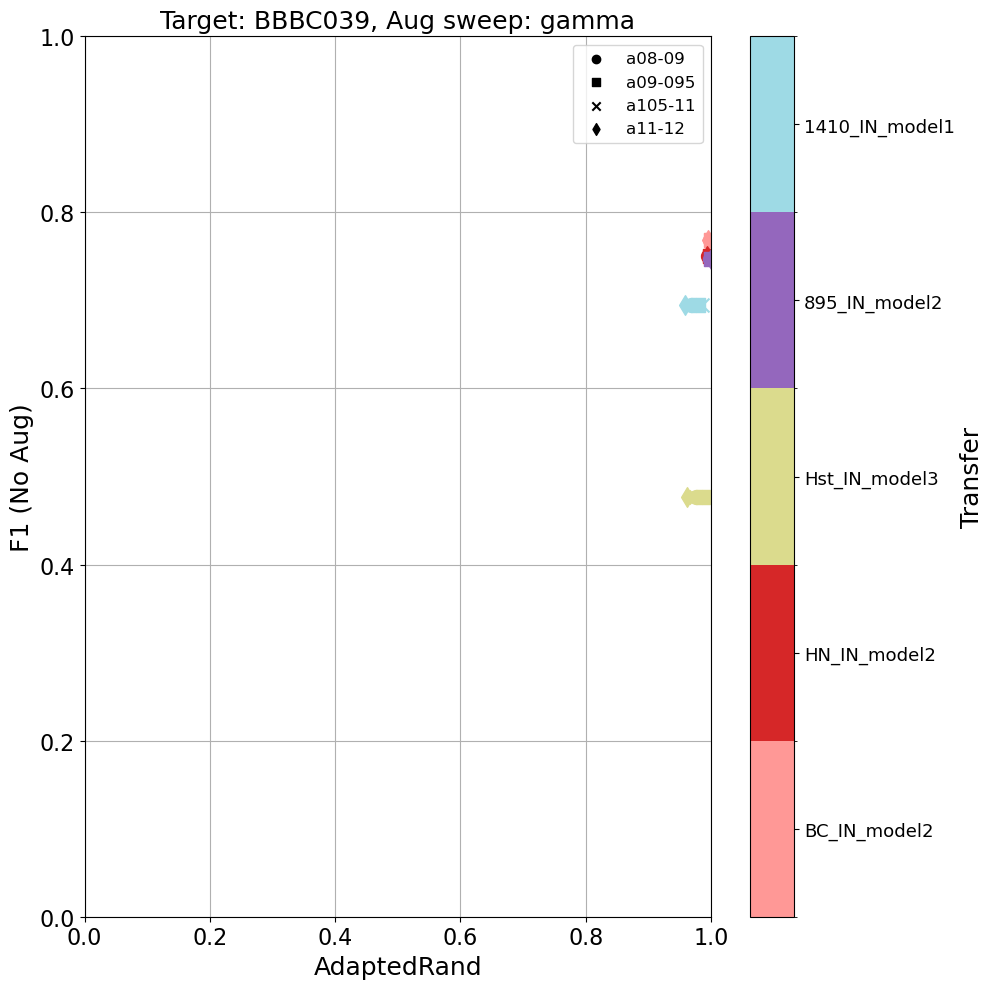

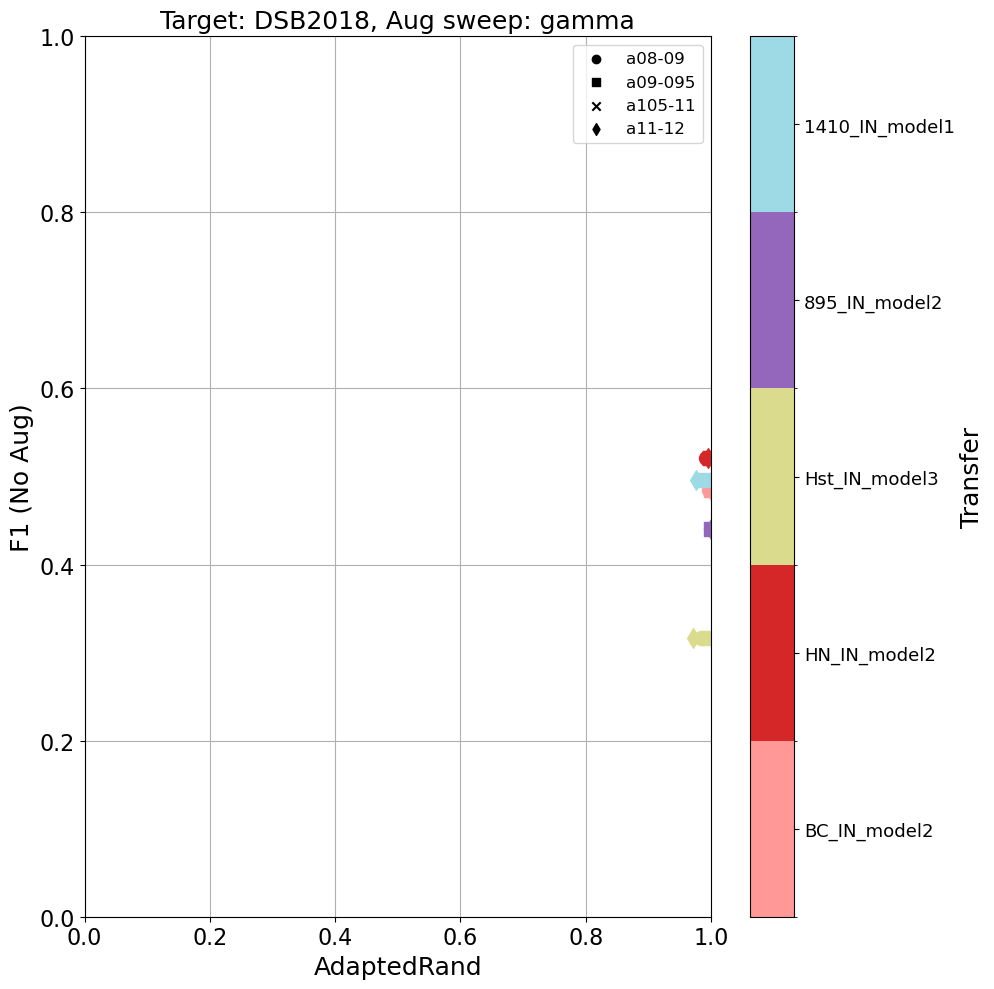

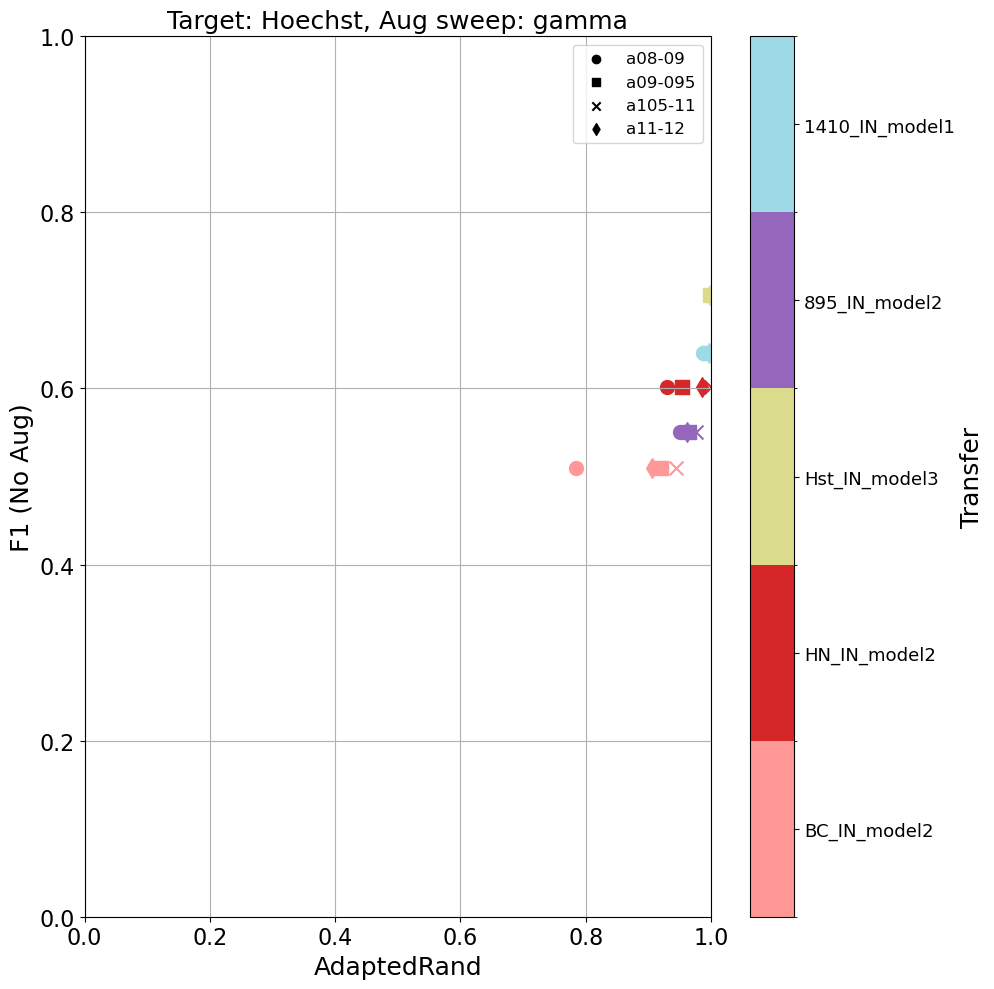

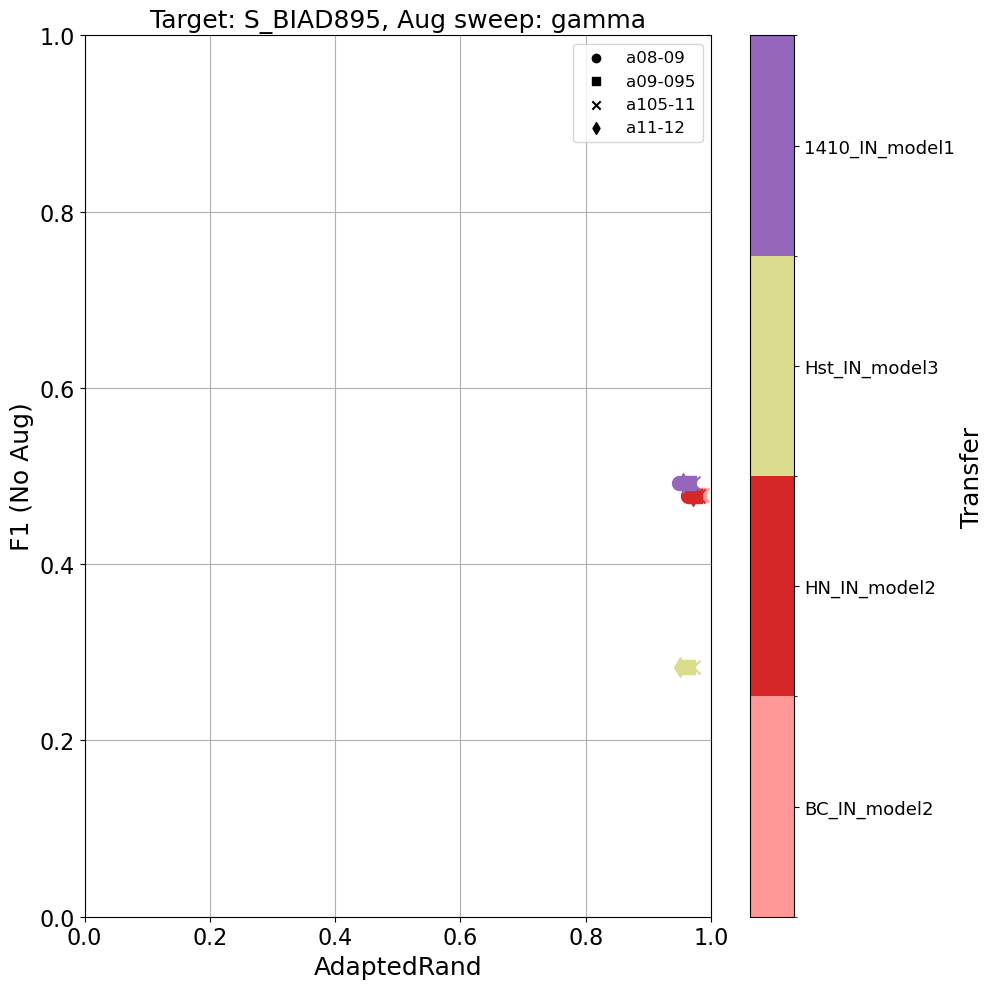

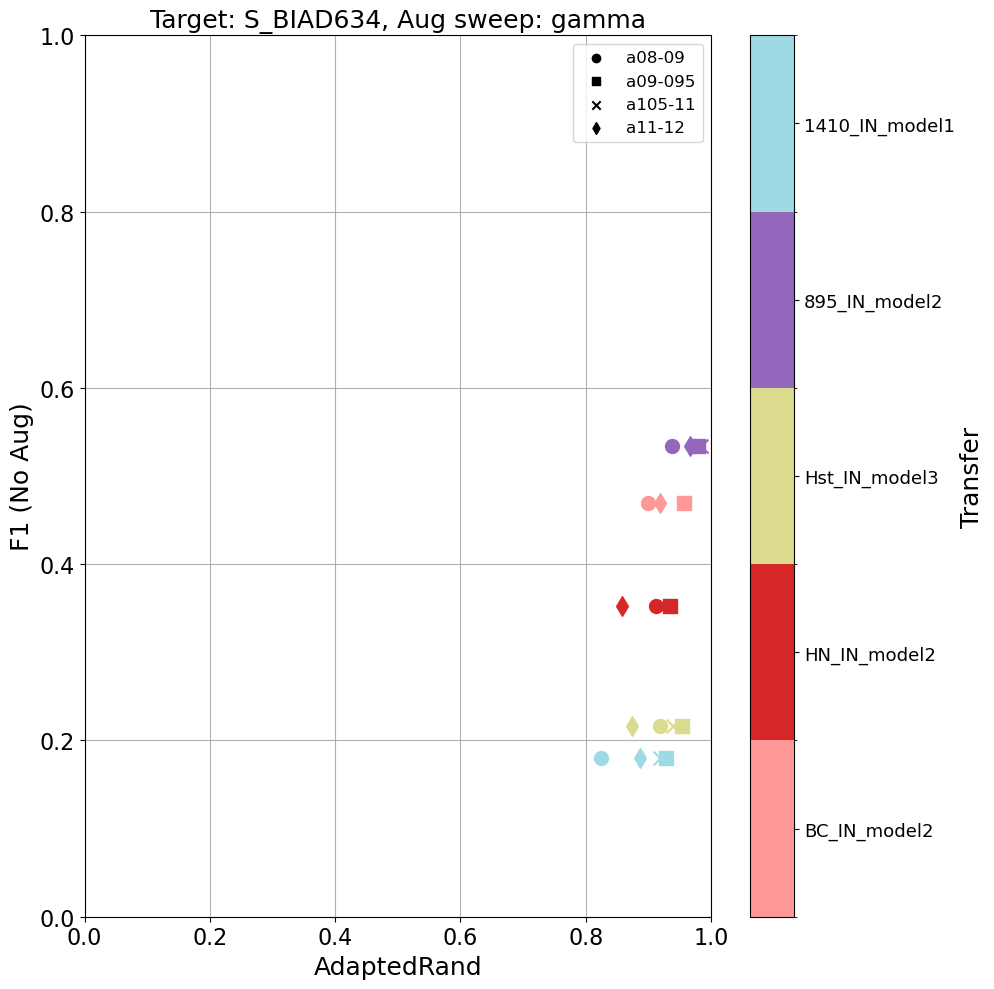

In [6]:
for target in targets:
    plot_alpha_sweep_specific_norm(
        per_target_forg_consistency[target],
        per_target_forg_performance[target],
        augs=["gamma"],
        select_alphas=selected_augmentations,
        select_norms=per_target_norms,
        consistency_metric_name="AdaptedRand",
        invert_consis_metric= True,
        invert_perf_metric=False,
        pos_correlation_line=False,
        per_transfer_norms=False,
        single_target=target,
        xlim=(0, 1),
        n_rows=1,
        n_cols = 1,
    )

In [7]:
per_target_KT, per_target_SP, per_target_PE = to_target_transfer_correlations_with_norm(
    targets=targets,
    transfer_metric_per_target=per_target_forg_consistency,
    performance_per_target=per_target_forg_performance,
    num_aug_alphas=len(selected_augmentations["gamma"]),
    perturbation_key="gamma",
    invert_consis_score=True,
)
for i in range(len(selected_augmentations['gamma'])):
    print(f"gamma: {selected_augmentations['gamma'][i]}")
    df = correlation_table(
        per_target_KT,
        per_target_SP,
        per_target_PE,
        targets,
        idx=i,
    )
    print(df)

gamma: a08-09
                  kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                   
Mito BBBC039    0.40     0.49    0.6        0.39  0.62     0.26
     DSB2018   -0.20     0.81   -0.2        0.76  0.20     0.75
     Hoechst    0.80     0.09    0.9        0.10  0.82     0.09
     S_BIAD895 -0.33     0.75   -0.4        0.75  0.06     0.94
     S_BIAD634  0.40     0.46    0.6        0.33  0.64     0.25
gamma: a09-095
                  kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                   
Mito BBBC039    0.40     0.48    0.6        0.32  0.54     0.35
     DSB2018   -0.20     0.90   -0.2        0.81  0.35     0.56
     Hoechst    0.80     0.10    0.9        0.10  0.89     0.04
     S_BIAD895  0.33     0.75    0.4        0.75  0.58     0.42
     S_BIAD634  0.80     0.09    0.9        0.08  0.76     0.14
gamma: a105-11
                 kt  kt pval  s rho  s rho pval    pr  pr pv

# Save results

In [8]:
per_target_performance: Dict[str, Dict[str,float]] = {}
for target, per_model_performance in per_target_forg_performance.items():
    per_target_performance[target] = {}
    for model, performance in per_model_performance.items():
        if isinstance(performance, dict):
            per_target_performance[target][model] = performance['norm_5_98']
        else:
            per_target_performance[target][model] = performance

In [9]:
import json
import os
from model_ranking import convert_numpy_types

save_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/nuclei/transfer_results/consistency/ARE"
if not os.path.exists(save_path):
    os.makedirs(save_path)

for i, alpha in enumerate(selected_augmentations['gamma']):
    per_target_consistency: Dict[str, Dict[str,float]] = {}
    for target, per_model_consistency in per_target_forg_consistency.items():
        per_target_consistency[target] = {}
        for model, consistency in per_model_consistency.items():
            per_target_consistency[target][model] = consistency['norm_5_98']['gamma'][i]

    with open(os.path.join(save_path, f"transfer_Gamma_{alpha}_Forg_ARE_scores.json"), "w") as f:
        results: Dict[str, Any] = {
            "transfer_scores": convert_numpy_types(per_target_consistency),
        }
        json.dump(results, f, indent=4)

In [ ]:
save_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/nuclei/transfer_results/consistency"
if not os.path.exists(save_path):
    os.makedirs(save_path)
# with open(os.path.join(save_path, f"transfer_performance_MAP_scores.json"), "w") as f:
#     results: Dict[str, Any] = {
#         "performance_scores": convert_numpy_types(per_target_performance),
#     }
#     json.dump(results, f, indent=4)